In [ ]:
!pip install openml
!pip install torchtext
!pip install torch==2.3.0

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchtext
torchtext.disable_torchtext_deprecation_warning()
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import openml

## 2.1 Датасет [Bank](https://www.openml.org/search?type=data&id=1461&sort=runs&status=active)

In [3]:
task = openml.tasks.get_task(233110)
df = task.get_dataset()
X, y, categorical_indicator, attribute_names = df.get_data(target=task.target_name)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0.0,unknown
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0.0,unknown
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0.0,unknown
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0.0,unknown
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0.0,unknown


In [4]:
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
def concatenate_text(x):
    age = x.iloc[0]
    job = x.iloc[1]
    marital = x.iloc[2]
    education = x.iloc[3]
    default = x.iloc[4]
    balance = x.iloc[5]
    housing = x.iloc[6]
    loan  = x.iloc[7]
    contact = x.iloc[8]
    day = x.iloc[9]
    month = x.iloc[10]
    duration = x.iloc[11]
    campaign = x.iloc[12]
    pdays = x.iloc[13]
    previous = x.iloc[14]
    poutcome = x.iloc[15]

    if default == "yes":
        df_text = "he has a credit in default"
    else:
        df_text = "he does not have credits in default"

    if housing == "yes":
        hs_text = "he has a housing loan"
    else:
        hs_text = "he does not have a housing loan"

    if loan == "yes":
        ln_text = "he has a personal loan"
    else:
        ln_text = "he does not have a personal loan"

    if pdays == -1:
        prev_text = "we have not contacted him previously"
    else:
        prev_text = f'previously we have contacted him {previous} times, the last time was {pdays} days ago, and it was {poutcome}'

    full_text = (
        f"This customer is {age} years old, "
        f"his job is {job}, "
        f"his marital status is {marital}, "
        f"his education is {education}, "
        f"his average yearly balance is {balance} euros, "
        f"{df_text}, "
        f"{hs_text}, "
        f"{ln_text}, "
        f"our last contact to him was on the {day}th of {month}, "
        f"the contact communication type was {contact}, "
        f"during this campaign we have called him {campaign} times, "
        f"{prev_text}."
    )
    return full_text

X["text"] = X.apply(concatenate_text, axis=1)

In [6]:
texts = X["text"].tolist()
labels = y.tolist()

In [7]:
tokenizer = get_tokenizer("basic_english")

def yield_tokens(text_list):
    for text in text_list:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(yield_tokens(texts), specials=["<pad>", "<unk>"])
print(len(vocab))
vocab.set_default_index(vocab["<unk>"])
PAD_IDX = vocab["<pad>"]

7288


In [8]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, tokenizer):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        tokens = self.tokenizer(text)
        tokens_ind = [self.vocab[token] for token in tokens]
        return torch.tensor(tokens_ind), torch.tensor(label)

In [9]:
def collate_fn(batch):
    data, labels = zip(*batch)
    data_padded = pad_sequence(data, batch_first=True, padding_value=PAD_IDX)
    labels = torch.stack(labels)
    return data_padded, labels

train_data, test_data, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=0, stratify=labels)
test_data, valid_data, test_labels, valid_labels = train_test_split(test_data, test_labels, test_size=0.5, random_state=0, stratify=test_labels)

train_dataset = TextDataset(train_data, train_labels, vocab, tokenizer)
test_dataset  = TextDataset(test_data, test_labels, vocab, tokenizer)
valid_dataset = TextDataset(valid_data, valid_labels, vocab, tokenizer)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [10]:
def plot_loss(train_losses, val_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='train')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='valid')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

@torch.no_grad()
def test(model, loader, criterion):
    loss_log = []
    model.eval()
    for data, target in tqdm(loader, desc="Validating"):
        data = data.to(device)
        target = target.to(device)
        
        logits = model(data)
        loss = criterion(logits, target)
        loss_log.append(loss.item())
        
    return np.mean(loss_log)

def train_epoch(model, optimizer, train_loader, criterion):
    loss_log = []
    model.train()
    for data, target in tqdm(train_loader, desc="Training"):
        data = data.to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()
        
        loss_log.append(loss.item())
  
    return np.mean(loss_log)

def train(model, optimizer, n_epochs, train_loader, val_loader, criterion, scheduler=None):
    train_loss_log = []
    val_loss_log = []
    
    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, optimizer, train_loader, criterion)
        val_loss = test(model, val_loader, criterion)
        train_loss_log.append(train_loss)
        val_loss_log.append(val_loss)
        
        plot_loss(train_loss_log, val_loss_log)
        if scheduler is not None:
            scheduler.step(val_loss)
            
        print(f"Epoch {epoch}: train loss = {train_loss:.4f} ; valid loss = {val_loss:.4f}")

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch.nn.functional as F

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_targets = []
    all_probs = []
    all_preds = []
    for data, target in loader:
        data = data.to(device)
        target = target.to(device)
        logits = model(data)
        pos_probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_targets.extend(target.cpu().numpy())
        all_probs.extend(pos_probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
    return np.array(all_targets), np.array(all_probs), np.array(all_preds)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2.2 LSTM

In [20]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=768, num_layers=1, num_classes=2):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, text):
        embedded = self.embedding(text)  
        _, (hidden, _) = self.lstm(embedded)
        return self.fc(hidden[-1])

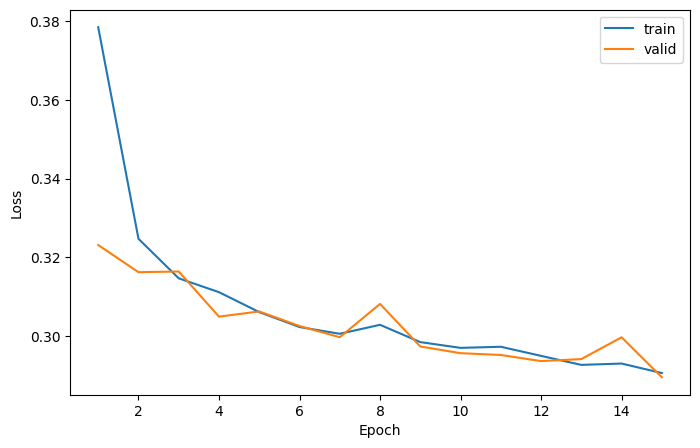

Epoch 15: train loss = 0.2906 ; valid loss = 0.2895


In [21]:
vocab_size = len(vocab)
model = LSTMClassifier(vocab_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, 15, train_loader, valid_loader, criterion, scheduler=None)

In [22]:
y_true, y_prob, y_pred = evaluate(model, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.7773
F1 = 0.2671
Accuracy = 0.8932
Precision = 0.6769
Recall = 0.1664


## 2.3 Transformer

In [16]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, emb_size, dropout, maxlen):
        super(PositionalEncoding, self).__init__()
        den = torch.exp(-torch.arange(0, emb_size, 2) * math.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)
        pos_embedding = torch.zeros((maxlen, emb_size))
        pos_embedding[:, 0::2] = torch.sin(pos * den)
        pos_embedding[:, 1::2] = torch.cos(pos * den)
        pos_embedding = pos_embedding.unsqueeze(0)

        self.dropout = nn.Dropout(dropout)
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, token_embedding: torch.tensor):
        return self.dropout(token_embedding + self.pos_embedding[:, :token_embedding.size(1), :])


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, num_heads=8, num_layers=3, num_classes=2, dropout=0.1, maxlen=112):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(emb_size=embed_dim, dropout=dropout, maxlen=maxlen)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
    
    def forward(self, text):
        embedded = self.embedding(text)
        embedded = self.pos_encoder(embedded)
        output = self.transformer_encoder(embedded)
        pooled = output.mean(dim=1)
        return self.fc(pooled)

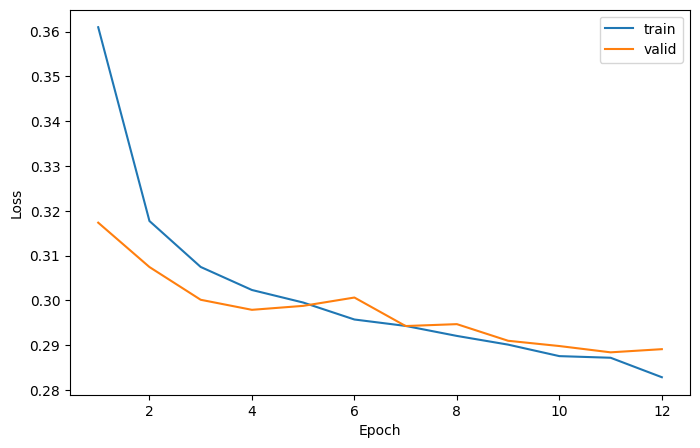

Epoch 12: train loss = 0.2829 ; valid loss = 0.2891


In [25]:
model = TransformerClassifier(vocab_size, embed_dim=512, num_heads=8, num_layers=2, dropout=0.1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, 12, train_loader, valid_loader, criterion, scheduler=None)

In [27]:
y_true, y_prob, y_pred = evaluate(model, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.8032
F1 = 0.3910
Accuracy = 0.8918
Precision = 0.5730
Recall = 0.2968
